## Importing Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

In [2]:
base_path = "Tomato" 

train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "validation")
test_path = os.path.join(base_path, "test")

# EDA(Exploratory Data Analysis)
## 1. Class Distribution Analysis:
#### Count Images Per Class:

In [3]:
def count_images(folder_path):
    class_counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            class_counts[class_name] = len(os.listdir(class_folder))
    return class_counts

train_counts = count_images(train_path)
val_counts = count_images(val_path)
test_counts = count_images(test_path)

df_train = pd.DataFrame(train_counts.items(), columns=["Class", "Train_Count"])
df_val = pd.DataFrame(val_counts.items(), columns=["Class", "Validation_Count"])
df_test = pd.DataFrame(test_counts.items(), columns=["Class", "Test_Count"])

df_all = df_train.merge(df_val, on="Class").merge(df_test, on="Class")
df_all

,Class,Train_Count,Validation_Count,Test_Count
0,Tomato_Bacterial_spot,1000,213,213
1,Tomato_Early_blight,1000,100,100
2,Tomato_healthy,1000,160,159
3,Tomato_Late_blight,1000,191,191
4,Tomato_Leaf_Mold,1000,96,95
5,Tomato_mosaic_virus,1000,38,37
6,Tomato_Septoria_leaf_spot,1000,178,177
7,Tomato_Spider_mites_Two_spotted_spider_mite,1000,168,168
8,Tomato_Target_Spot,1000,141,140
9,Tomato_YellowLeaf_Curl_Virus,1000,321,321


In [4]:
train_path = Path('Tomato/train')
data = []
for category in os.listdir(train_path):
    category_path = train_path / category
    if category_path.is_dir():
        for img_name in os.listdir(category_path):
            data.append({'path': str(category_path / img_name), 'label': category})

df = pd.DataFrame(data)
print(f"Total training images found: {len(df)}")

Total training images found: 10000


## 2. Visualize Class Distribution:

C:\Users\Microsoft\AppData\Local\Temp\ipykernel_20188\3499269246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', palette='viridis')


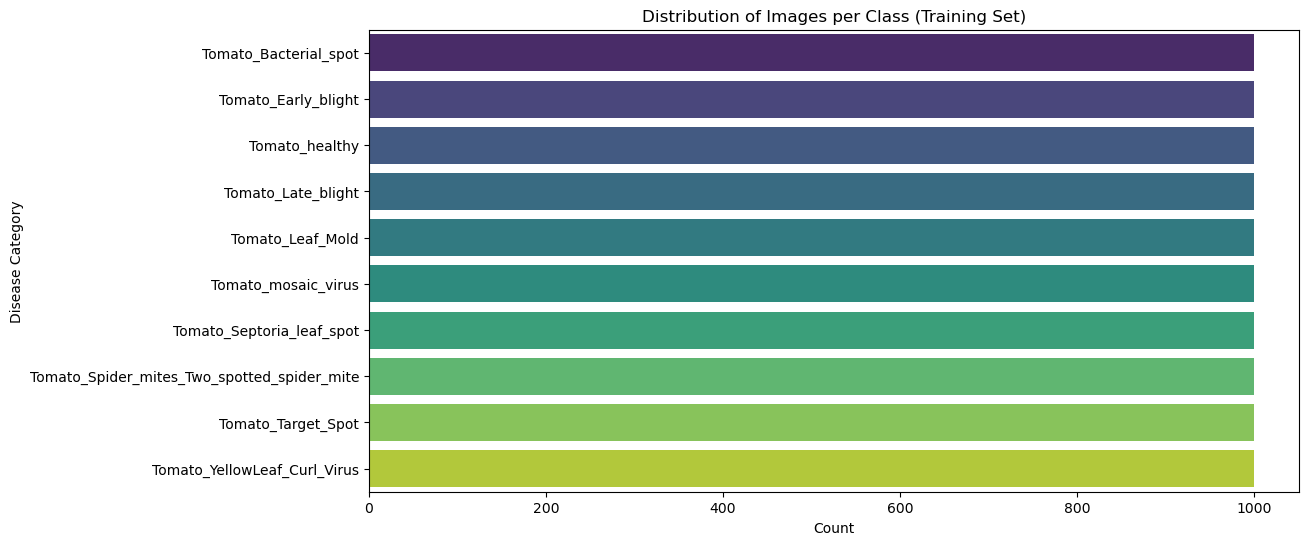

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label', palette='viridis')
plt.title('Distribution of Images per Class (Training Set)')
plt.xlabel('Count')
plt.ylabel('Disease Category')
plt.show()

## 3. Class Distribution Graph:

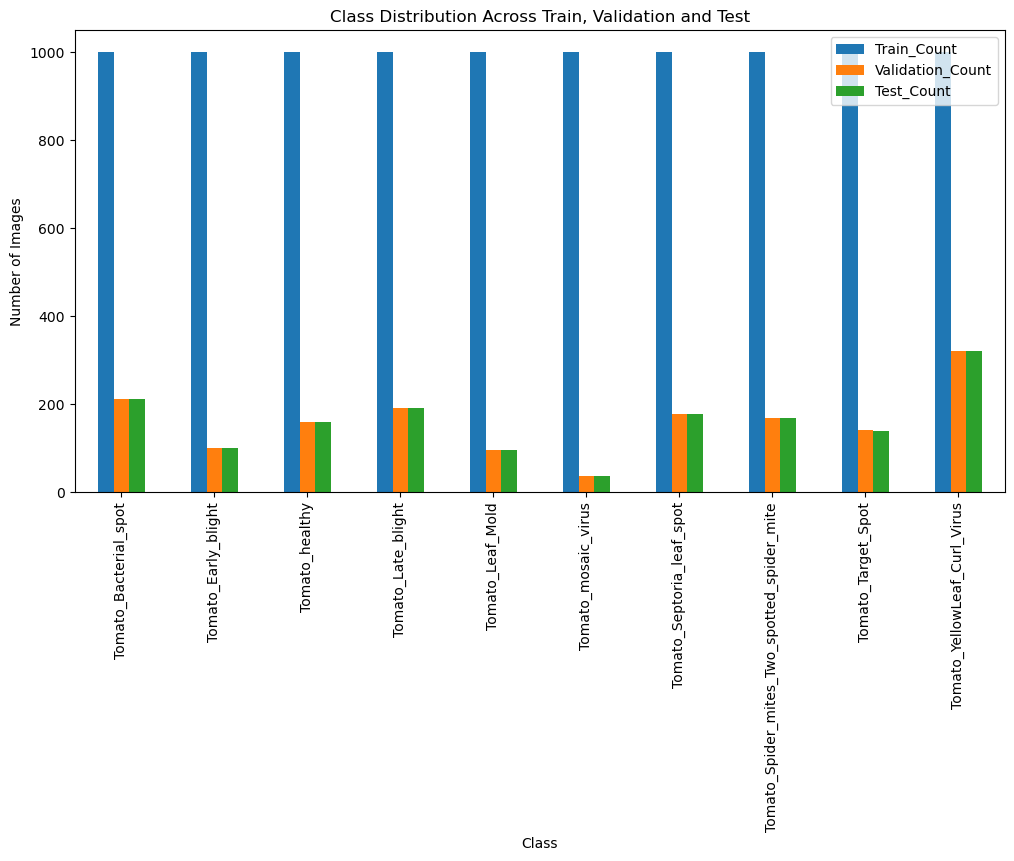

In [6]:
df_all.set_index("Class").plot(kind="bar", figsize=(12,6))
plt.title("Class Distribution Across Train, Validation and Test")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

# 4. Image-Level EDA
## Image Size Analysis:

In [7]:
img = Image.open(df['path'].iloc[0])
print(f"Sample Image Size: {img.size}")

Sample Image Size: (256, 256)


In [8]:
dims = []
for path in df['path'][:500]:
    with Image.open(path) as img:
        dims.append(img.size)

dims_df = pd.DataFrame(dims, columns=['Width', 'Height'])
print(dims_df.describe())

       Width  Height
count  500.0   500.0
mean   256.0   256.0
std      0.0     0.0
min    256.0   256.0
25%    256.0   256.0
50%    256.0   256.0
75%    256.0   256.0
max    256.0   256.0


In [9]:
sizes = []
for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_folder)[:100]:
        img_path = os.path.join(class_folder, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)
widths = [size[0] for size in sizes]
heights = [size[1] for size in sizes]
print("Average Width:", np.mean(widths))
print("Average Height:", np.mean(heights))
print("Minimum Width:", np.min(widths))
print("Maximum Width:", np.max(widths))

Average Width: 256.0
Average Height: 256.0
Minimum Width: 256
Maximum Width: 256


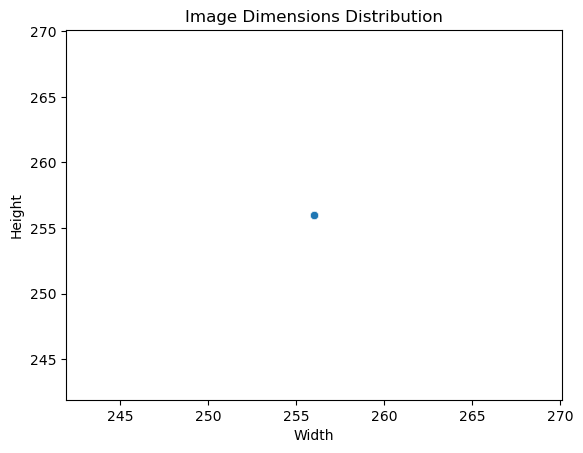

In [10]:
sns.scatterplot(x='Width', y='Height', data=dims_df)
plt.title('Image Dimensions Distribution')
plt.show()

## 5. Display Sample Images:

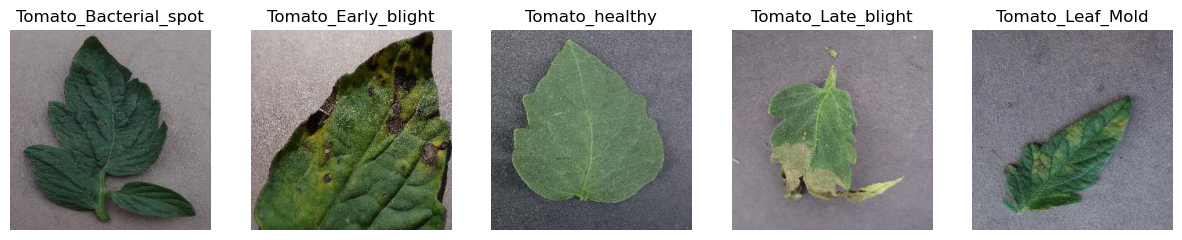

In [11]:
def show_samples(folder_path, num_classes=5):
    classes = os.listdir(folder_path)[:num_classes]
    
    plt.figure(figsize=(15,8))
    for i, class_name in enumerate(classes):
        img_name = os.listdir(os.path.join(folder_path, class_name))[0]
        img_path = os.path.join(folder_path, class_name, img_name)
        img = Image.open(img_path)
        
        plt.subplot(1, num_classes, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

show_samples(train_path)

# 6. Pixel Intensity Analysis
## Pixel Distribution:

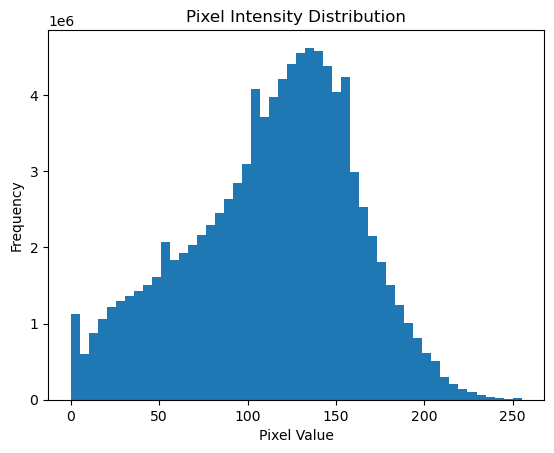

In [12]:
sample_pixels = []

for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_folder)[:50]:
        img = Image.open(os.path.join(class_folder, img_name)).convert("RGB")
        img_array = np.array(img)
        sample_pixels.extend(img_array.flatten())

sample_pixels = np.array(sample_pixels)

plt.hist(sample_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

## 6. RGB Channel Analysis

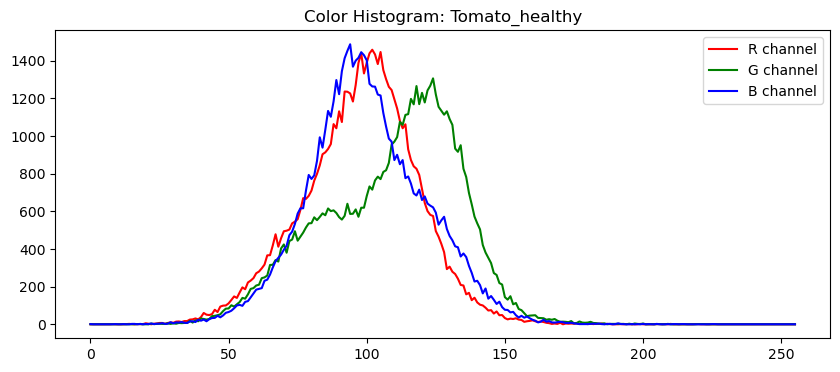

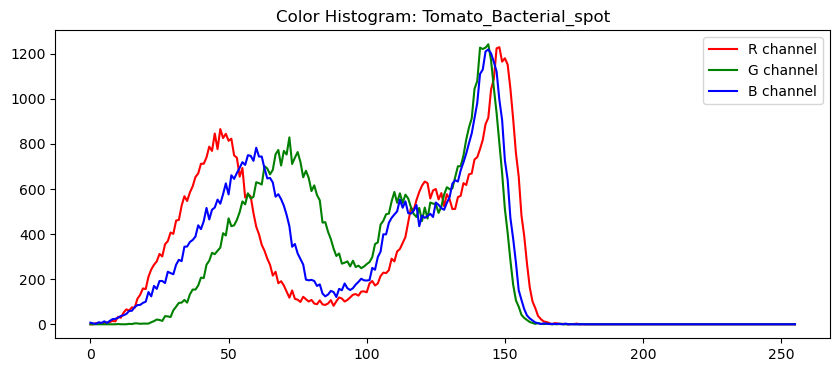

In [13]:
def plot_color_distribution(img_path):
    img = np.array(Image.open(img_path))
    colors = ('r', 'g', 'b')
    plt.figure(figsize=(10, 4))
    
    for i, col in enumerate(colors):
        hist = np.histogram(img[:, :, i], bins=256, range=(0, 255))[0]
        plt.plot(hist, color=col, label=f'{col.upper()} channel')
    
    plt.title(f'Color Histogram: {Path(img_path).parent.name}')
    plt.legend()
    plt.show()
plot_color_distribution(df[df['label'] == 'Tomato_healthy']['path'].iloc[0])
plot_color_distribution(df[df['label'] != 'Tomato_healthy']['path'].iloc[0])

In [14]:
def average_rgb(folder_path):
    r_vals, g_vals, b_vals = [], [], []
    
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        for img_name in os.listdir(class_folder)[:50]:
            img = Image.open(os.path.join(class_folder, img_name)).convert("RGB")
            arr = np.array(img)
            r_vals.append(np.mean(arr[:,:,0]))
            g_vals.append(np.mean(arr[:,:,1]))
            b_vals.append(np.mean(arr[:,:,2]))
    
    return np.mean(r_vals), np.mean(g_vals), np.mean(b_vals)

avg_r, avg_g, avg_b = average_rgb(train_path)

print("Average Red:", avg_r)
print("Average Green:", avg_g)
print("Average Blue:", avg_b)

Average Red: 115.36928842163086
Average Green: 118.15719049072266
Average Blue: 106.83166119384765


## 7. Checking Corrupted Images

In [15]:
bad_images = []

for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_folder):
        try:
            img = Image.open(os.path.join(class_folder, img_name))
            img.verify()
        except:
            bad_images.append(img_name)

print("Total Corrupted Images:", len(bad_images))

Total Corrupted Images: 0


# Preprocessing Steps

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

C:\Users\Microsoft\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [17]:
train_dir = "Tomato/train"
val_dir = "Tomato/validation"
test_dir = "Tomato/test"

In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

### Data Augmentation

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,         
    width_shift_range=0.25,     
    height_shift_range=0.25,    
    shear_range=0.2,            
    zoom_range=0.3,            
    horizontal_flip=True,
    vertical_flip=True,         
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

### Validation & Test Preprocessing

In [20]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

### Data Generators
#### Training Generator

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 10000 images belonging to 10 classes.


#### Validation Generator

In [22]:
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1606 images belonging to 10 classes.


#### Test Generator

In [23]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  
)

Found 1601 images belonging to 10 classes.


#### Verify Generator Output

In [24]:
print(f"\nTraining   batches : {len(train_generator)}")
print(f"Validation batches : {len(val_generator)}")
print(f"Test       batches : {len(test_generator)}")

images, labels = next(train_generator)
print(f"\nBatch shape  : {images.shape}")        
print(f"Label shape  : {labels.shape}")          
print(f"Pixel range  : [{images.min():.2f}, {images.max():.2f}]")  



Training   batches : 313
Validation batches : 51
Test       batches : 51

Batch shape  : (32, 224, 224, 3)
Label shape  : (32, 10)
Pixel range  : [0.00, 1.00]


### Class Labels Mapping

In [25]:
class_indices = train_generator.class_indices
print("Class → Index Mapping:")
for cls, idx in class_indices.items():
    print(f"  {idx}: {cls}")

Class → Index Mapping:
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato_Target_Spot
  7: Tomato_YellowLeaf_Curl_Virus
  8: Tomato_healthy
  9: Tomato_mosaic_virus


### Visualize Preprocessed Images

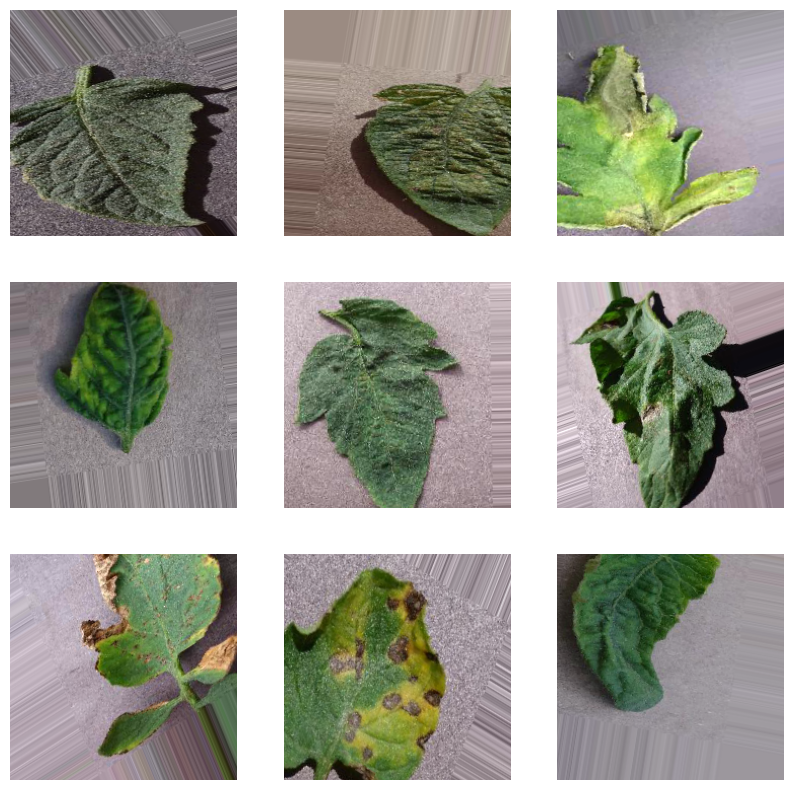

In [26]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

### Handle Class Imbalance

In [27]:
from sklearn.utils.class_weight import compute_class_weight
classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0}


In [28]:
print(train_generator.class_indices)

{'Tomato_Bacterial_spot': 0, 'Tomato_Early_blight': 1, 'Tomato_Late_blight': 2, 'Tomato_Leaf_Mold': 3, 'Tomato_Septoria_leaf_spot': 4, 'Tomato_Spider_mites_Two_spotted_spider_mite': 5, 'Tomato_Target_Spot': 6, 'Tomato_YellowLeaf_Curl_Virus': 7, 'Tomato_healthy': 8, 'Tomato_mosaic_virus': 9}


In [62]:
class_weights[5] *= 3.0  
class_weights[6] *= 3.0 
class_weights[8] *= 0.3   
class_weights[3] *= 1.5
class_weights[2] *= 1.3  

# Custom CNN

In [63]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [64]:
NUM_CLASSES = 10

### Building Model

In [ ]:
def build_custom_cnn():
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(224,224,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2))) 

    # Block 2
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2))) 

    # Block 3
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))  

    # Block 4 
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2))) 

    # Block 5 
    model.add(layers.Conv2D(512, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2))) 
    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    return model

model = build_custom_cnn()

C:\Users\Microsoft\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Output Layer and Compile Model

In [66]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(), 
    metrics=['accuracy']
)

In [67]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 14, 14, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 14, 14, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 14, 14, 512)         │              

 Total params: 1,842,378 (7.03 MB)

 Trainable params: 1,839,370 (7.02 MB)

 Non-trainable params: 3,008 (11.75 KB)

### Add Callbacks

In [68]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [69]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,          
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,         
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    'best_tomato_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

### Training

In [70]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,           
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 830s 3s/step - accuracy: 0.5475 - loss: 2.0341 - val_accuracy: 0.4309 - val_loss: 2.5429 - learning_rate: 3.0000e-04
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 811s 3s/step - accuracy: 0.6971 - loss: 1.3338 - val_accuracy: 0.6314 - val_loss: 1.3347 - learning_rate: 3.0000e-04
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 813s 3s/step - accuracy: 0.7606 - loss: 1.0244 - val_accuracy: 0.6955 - val_loss: 1.1956 - learning_rate: 3.0000e-04
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 813s 3s/step - accuracy: 0.8036 - loss: 0.8645 - val_accuracy: 0.7665 - val_loss: 0.7190 - learning_rate: 3.0000e-04
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 813s 3s/step - accuracy: 0.8196 - loss: 0.7629 - val_accuracy: 0.7659 - val_loss: 0.7801 - learning_rate: 3.0000e-04
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 2318s 7s/step - accuracy: 0.8476 - loss: 0.6560 - val_accuracy: 0.7011 - val_loss: 1.2664 - learning_rate: 3.0000e-04
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 814s 3s/step - ac

### Evaluation on Test Data

In [71]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 546ms/step - accuracy: 0.9238 - loss: 0.2142
Test Accuracy: 0.923797607421875


### Accuracy & Loss Graphs

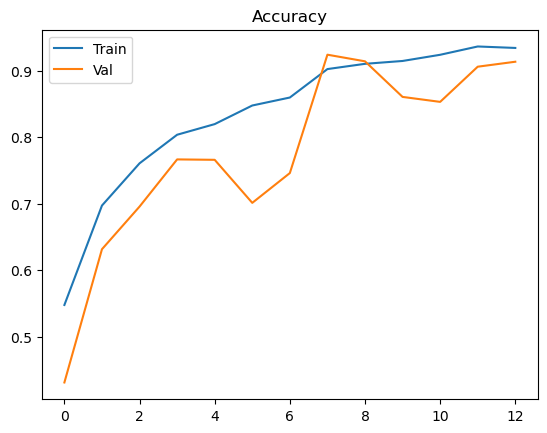

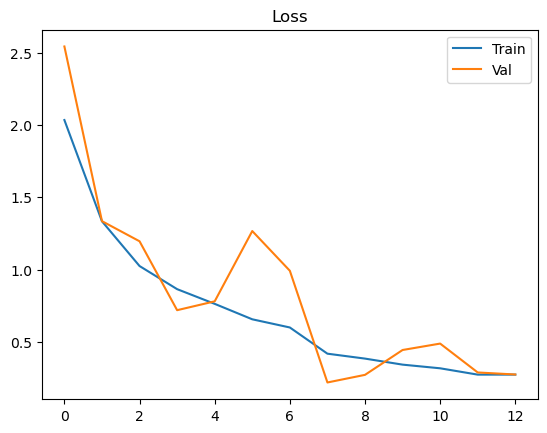

In [72]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Val'])
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Val'])
plt.title('Loss')
plt.show()

# Confusion Matrix

In [73]:
from sklearn.metrics import confusion_matrix

51/51 ━━━━━━━━━━━━━━━━━━━━ 30s 573ms/step


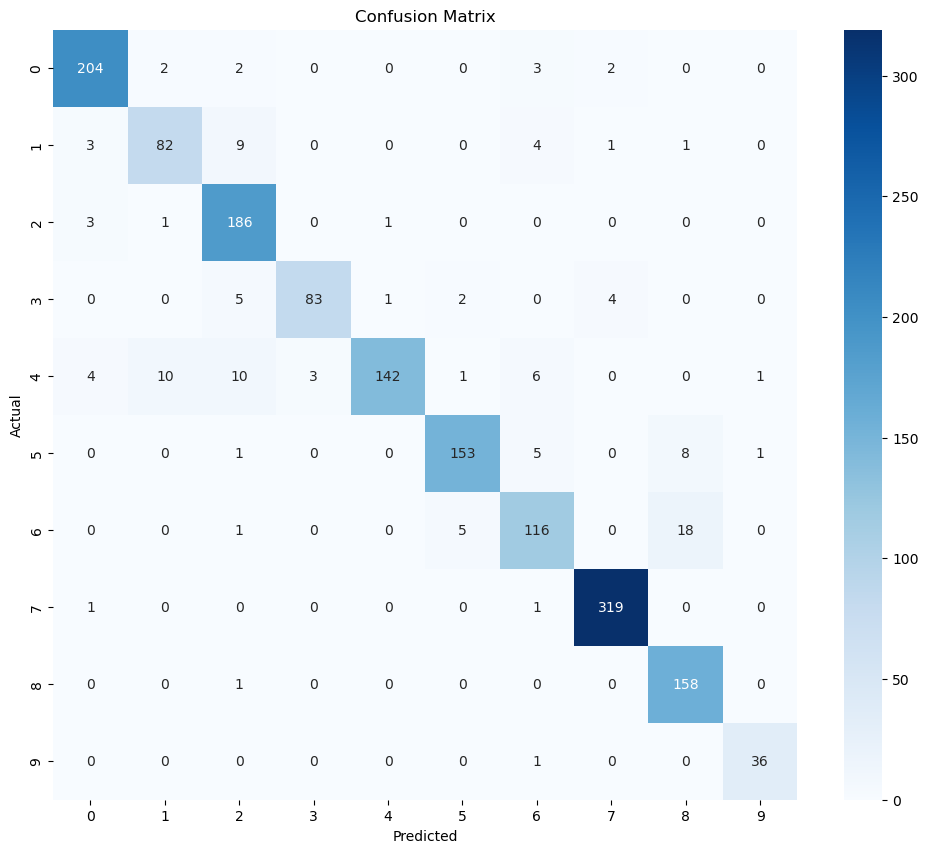

In [74]:
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Classification Report (Precision, Recall, F1)

In [75]:
from sklearn.metrics import classification_report

In [76]:
class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.95      0.96      0.95       213
                        Tomato_Early_blight       0.86      0.82      0.84       100
                         Tomato_Late_blight       0.87      0.97      0.92       191
                           Tomato_Leaf_Mold       0.97      0.87      0.92        95
                  Tomato_Septoria_leaf_spot       0.99      0.80      0.88       177
Tomato_Spider_mites_Two_spotted_spider_mite       0.95      0.91      0.93       168
                         Tomato_Target_Spot       0.85      0.83      0.84       140
               Tomato_YellowLeaf_Curl_Virus       0.98      0.99      0.99       321
                             Tomato_healthy       0.85      0.99      0.92       159
                        Tomato_mosaic_virus       0.95      0.97      0.96        37

                                   accuracy                    

# VGG16 Transfer Learning

In [113]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.applications.vgg16 import preprocess_input

In [114]:
classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0}


In [115]:
IMG_SIZE = (160, 160)

In [116]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [117]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160,160),  
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(160,160),   
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(160,160),   
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 10000 images belonging to 10 classes.
Found 1606 images belonging to 10 classes.
Found 1601 images belonging to 10 classes.


### Load Pretrained Model

In [118]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(160,160,3)
)

### Freeze Layers

In [119]:
base_model.trainable = False

In [120]:
for layer in base_model.layers[-6:]:
    layer.trainable = True

### Build Custom Head

In [121]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x) 
x = layers.Dropout(0.4)(x)

output = layers.Dense(10, activation='softmax')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

### Compile

In [122]:
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Callbacks

In [123]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [124]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=1,
    min_lr=1e-6
)

### Train Model

In [125]:
history_vgg = model_vgg.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1642s 5s/step - accuracy: 0.3391 - loss: 2.1581 - val_accuracy: 0.6762 - val_loss: 1.0157 - learning_rate: 1.0000e-05
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1265s 4s/step - accuracy: 0.6794 - loss: 0.9745 - val_accuracy: 0.8630 - val_loss: 0.4738 - learning_rate: 1.0000e-05
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1244s 4s/step - accuracy: 0.8174 - loss: 0.5847 - val_accuracy: 0.9334 - val_loss: 0.2753 - learning_rate: 1.0000e-05
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33841s 108s/step - accuracy: 0.8804 - loss: 0.3955 - val_accuracy: 0.9465 - val_loss: 0.2155 - learning_rate: 1.0000e-05
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1660s 5s/step - accuracy: 0.9095 - loss: 0.3029 - val_accuracy: 0.9676 - val_loss: 0.1534 - learning_rate: 1.0000e-05
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1632s 5s/step - accuracy: 0.9280 - loss: 0.2426 - val_accuracy: 0.9701 - val_loss: 0.1307 - learning_rate: 1.0000e-05
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1632s 5s/

### Evaluate VGG Model

In [126]:
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_generator)
print("VGG Test Accuracy:", test_acc_vgg)

51/51 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.9806 - loss: 0.0639
VGG Test Accuracy: 0.9806370735168457


# Accuracy & Loss Graphs

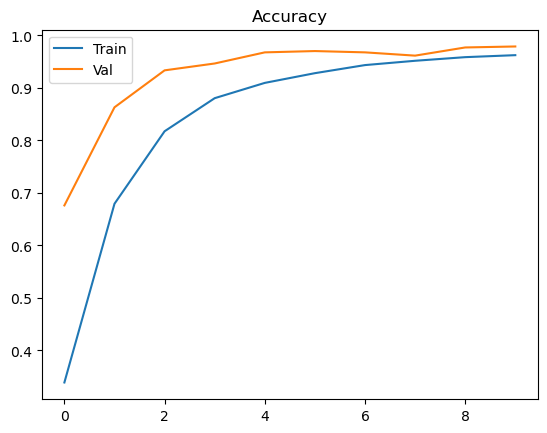

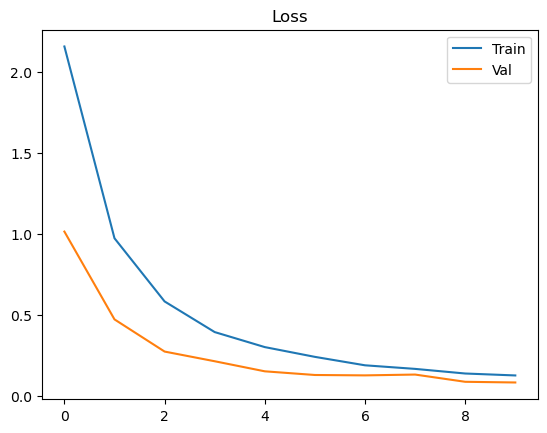

In [127]:
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.legend(['Train', 'Val'])
plt.title('Accuracy')
plt.show()

plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.legend(['Train', 'Val'])
plt.title('Loss')
plt.show()

### Confusion Matrix

51/51 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step


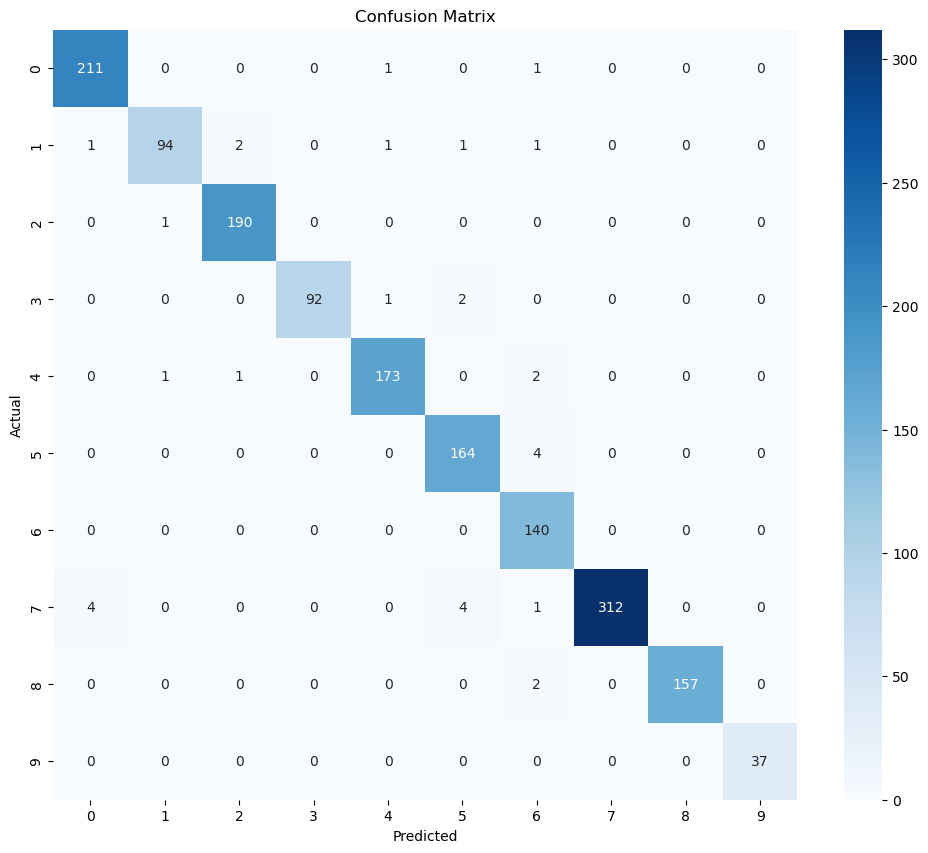

In [128]:
y_true = test_generator.classes
y_pred_probs = model_vgg.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Classification Report (Precision, Recall, F1)

In [129]:
class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.98      0.99      0.98       213
                        Tomato_Early_blight       0.98      0.94      0.96       100
                         Tomato_Late_blight       0.98      0.99      0.99       191
                           Tomato_Leaf_Mold       1.00      0.97      0.98        95
                  Tomato_Septoria_leaf_spot       0.98      0.98      0.98       177
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.98      0.97       168
                         Tomato_Target_Spot       0.93      1.00      0.96       140
               Tomato_YellowLeaf_Curl_Virus       1.00      0.97      0.99       321
                             Tomato_healthy       1.00      0.99      0.99       159
                        Tomato_mosaic_virus       1.00      1.00      1.00        37

                                   accuracy                    